# **Sea Level Prediction Analysis: Montauk**

# Importing Libraries

In [ ]:
# Install the Prophet library (used for time series forecasting).
!pip install prophet holidays==0.28

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.9/642.9 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: holidays
    Found existing installation: holidays 0.100
    Uninstalling holidays-0.100:
      Successfully uninstalled holidays-0.100


In [ ]:
# --- Standard library imports ---
import warnings  # For controlling warning messages

# --- Core scientific Python stack ---
import numpy as np            # Numerical computing
import pandas as pd           # Data manipulation and analysis

# --- Visualization libraries ---
import matplotlib.pyplot as plt   # General plotting
import matplotlib.dates as mdates # Date formatting for plots
import seaborn as sns             # Statistical data visualization

# --- Forecasting library ---
from prophet import Prophet  # Facebook Prophet for time series forecasting

# --- Machine learning utilities ---
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Model evaluation metrics

# --- Pandas utilities ---
from pandas.api.types import CategoricalDtype  # For categorical data handling

# --- IPython display tools (for Jupyter/Colab) ---
from IPython.display import Image, display  # For displaying images inline

# --- Configure settings ---
warnings.filterwarnings("ignore")   # Suppress unnecessary warning messages
plt.style.use('ggplot')             # Apply ggplot style to plots
plt.style.use('fivethirtyeight')    # Override with FiveThirtyEight style

# --- Custom metric function ---
def mean_absolute_percentage_error(y_true, y_pred):
    """
    Calculates Mean Absolute Percentage Error (MAPE).

    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values

    Returns:
        float: MAPE percentage
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
# Import Google Colab's drive module, which allows access to Google Drive files
from google.colab import drive

# Mount Google Drive to the Colab environment so you can read/write files.
# '/content/drive' is the path where the drive will be mounted.
# force_remount=True ensures that the drive is re-mounted even if it was already mounted before.
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Loading Data into Pandas DataFrame

In [ ]:
# Define the file path to the CSV stored in Google Drive
csv_path = "/content/drive/MyDrive/sea_level_prediction/sea_level_prediction.csv"

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_path)

# Display the first 5 rows of the DataFrame to quickly preview the data
df.head()

,Year,Month,Monthly_MSL,Linear_Trend,High_Conf.,Low_Conf.
0,1947,10,-0.165,-0.141,-0.130,-0.152
1,1947,11,-0.021,-0.141,-0.130,-0.152
2,1947,12,-0.197,-0.140,-0.129,-0.151
3,1948,1,-0.152,-0.140,-0.129,-0.151
4,1948,2,-0.130,-0.140,-0.129,-0.151


# Preprocessing

In [ ]:
# Create a new column 'ds' (required by Prophet for dates)
df['ds'] = pd.to_datetime(df['Month'].astype(str) + '-' + df['Year'].astype(str))

# Display the first 5 rows to verify that the new 'ds' column was created correctly
df.head()

,Year,Month,Monthly_MSL,Linear_Trend,High_Conf.,Low_Conf.,ds
0,1947,10,-0.165,-0.141,-0.130,-0.152,1947-10-01
1,1947,11,-0.021,-0.141,-0.130,-0.152,1947-11-01
2,1947,12,-0.197,-0.140,-0.129,-0.151,1947-12-01
3,1948,1,-0.152,-0.140,-0.129,-0.151,1948-01-01
4,1948,2,-0.130,-0.140,-0.129,-0.151,1948-02-01


Code Block 2B

In [ ]:
# Set the 'ds' column as the DataFrame index
# This makes it easier to work with time series data, e.g., plotting or resampling by date
df.set_index('ds', inplace=True)

# Drop the original 'Month' and 'Year' columns as they are no longer needed
# The 'ds' column already contains the combined datetime information
df.drop(['Month', 'Year'], axis=1, inplace=True)

# Display the first 5 rows to confirm changes
df.head()

,Monthly_MSL,Linear_Trend,High_Conf.,Low_Conf.
ds,,,,
1947-10-01,-0.165,-0.141,-0.130,-0.152
1947-11-01,-0.021,-0.141,-0.130,-0.152
1947-12-01,-0.197,-0.140,-0.129,-0.151
1948-01-01,-0.152,-0.140,-0.129,-0.151
1948-02-01,-0.130,-0.140,-0.129,-0.151


# Visualize the Data

Code Block 3A

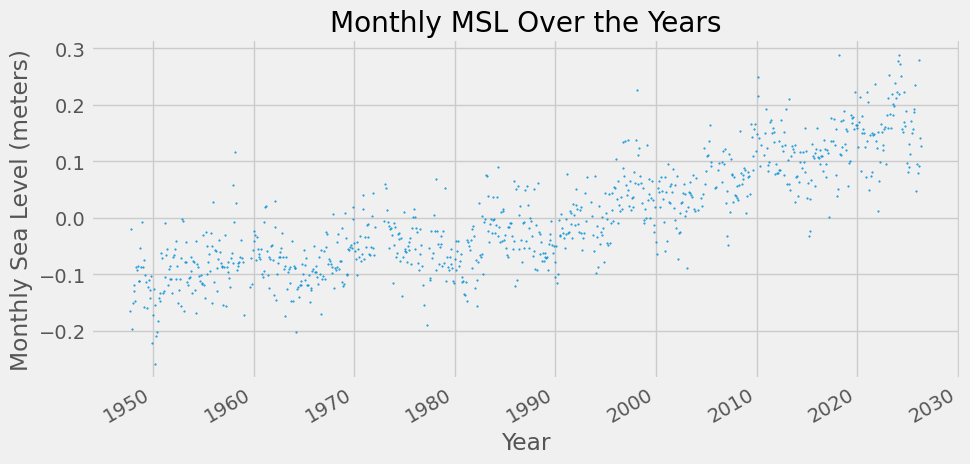

In [ ]:
# Get the default Seaborn color palette
color_pal = sns.color_palette()

# Plot the 'Monthly_MSL' column as a scatter plot
df['Monthly_MSL'].plot(
    style='.',                            # Use dots for each data point
    figsize=(10, 5),                      # Set the size of the figure (width x height in inches)
    ms=1,                                 # Marker size for the dots
    color=color_pal[0],                   # Use the first color from the Seaborn palette
    title='Monthly MSL Over the Years',   # Plot title
    xlabel='Year',                        # Label for the x-axis
    ylabel='Monthly Sea Level (meters)'   # Label for the y-axis
)

# Display the plot
plt.show()

Code Block 3B

In [ ]:
def plot_msl_by_year_range(df, start_year, end_year):
    """
    Plots the Monthly MSL levels for a given range of years with a rolling mean trend line.

    Args:
        df (pd.DataFrame): The input DataFrame with a datetime index and 'Monthly_MSL' column.
        start_year (int): The starting year for the plot.
        end_year (int): The ending year for the plot.
    """
    # Filter the DataFrame by year range
    df_filtered = df[(df.index.year >= start_year) & (df.index.year <= end_year)].copy()

    # Calculate a rolling mean for the trend line
    rolling_mean = df_filtered['Monthly_MSL'].rolling(window=12).mean()

    # Plot the Monthly MSL
    color_pal = sns.color_palette()
    ax = df_filtered['Monthly_MSL'].plot(style='.',
                                    figsize=(10, 5),
                                    ms=1,
                                    color=color_pal[0],
                                    title=f'Monthly MSL from {start_year} to {end_year}')

    # Plot the rolling mean as the trend line
    rolling_mean.plot(ax=ax, color='red', label='Rolling Mean Trend', alpha=0.5)

    # Add axis names
    ax.set_xlabel('Year')
    ax.set_ylabel('Monthly Sea Level (meters)')

    # Add legend
    ax.legend()

    plt.show()

Code Block 3C

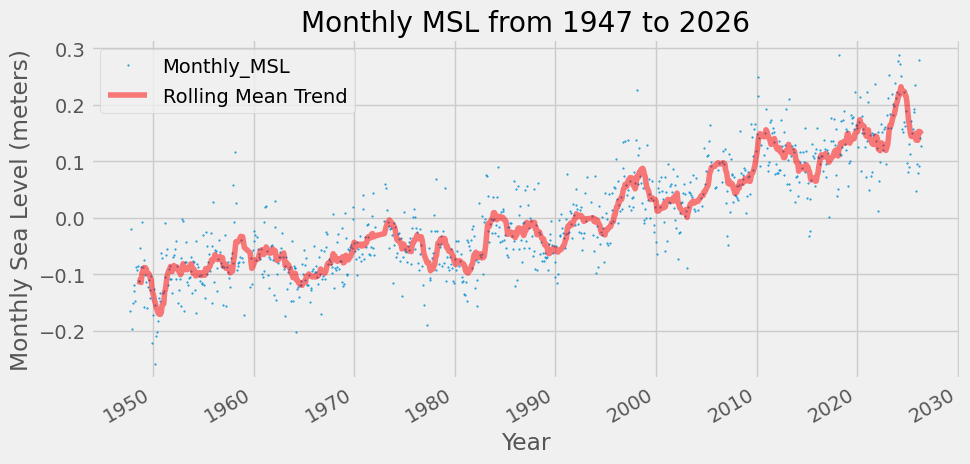

In [ ]:
# TODO: Change the years below to explore different time periods
start_year = 1947
end_year = 2026

# Plot the monthly sea level data and rolling average trend for the selected year range
plot_msl_by_year_range(df, start_year, end_year)

# Splitting Data into Train and Test

Code Block 4A

In [ ]:
# Create the feature set X by dropping the target column 'Monthly_MSL'
# X will contain all other columns that can be used as input for modeling
X = df.drop(columns=['Monthly_MSL'])

# Create the target variable y, which is the 'Monthly_MSL' column we want to predict
y = df['Monthly_MSL']

# Prepare data for Prophet: select 'Monthly_MSL' and rename to 'y'
prophet_df = df[['Monthly_MSL']].copy()
prophet_df = prophet_df.rename(columns={'Monthly_MSL': 'y'})

# Prophet requires a 'ds' column which is the datetime index
prophet_df['ds'] = prophet_df.index

Code Block 4B

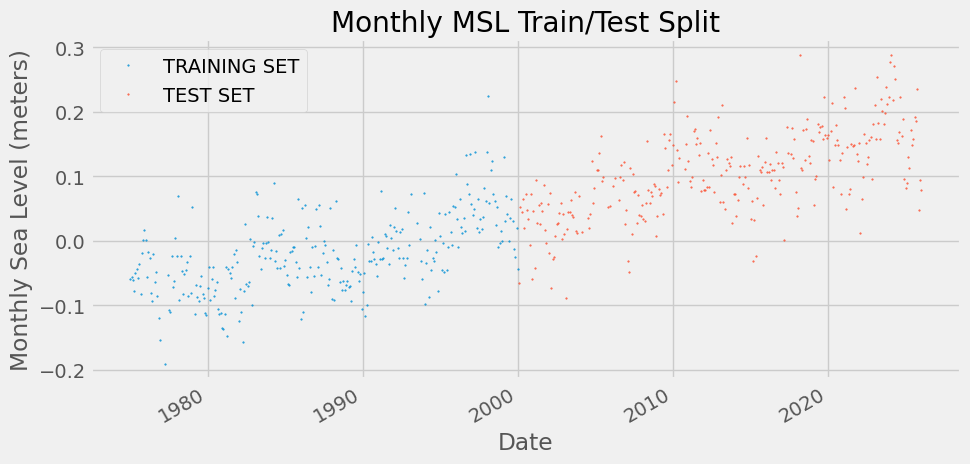

In [ ]:
# Split the data into training and testing sets based on a chosen date

# TODO: Update the dates to change how long to train for and how far in advance to predict
start_date = '1975-01-01'
split_date = '2000-01-01'
end_date = '2026-01-01'

# Training data: all rows on or before the split date
df_train_prophet = prophet_df.loc[(prophet_df['ds'] >= start_date) & (prophet_df['ds'] <= split_date)].copy()

# Testing data: all rows after the split date and before end date
df_test_prophet = prophet_df.loc[(prophet_df['ds'] > split_date) & (prophet_df['ds'] <= end_date)].copy()

# Plot the training and testing data on the same figure for visual inspection
fig, ax = plt.subplots(figsize=(10, 5))
df_train_prophet['y'].plot(ax=ax, style='.', ms=1, label='TRAINING SET')
df_test_prophet['y'].plot(ax=ax, style='.', ms=1, label='TEST SET')

# Add title and legend to the plot
ax.set_title('Monthly MSL Train/Test Split')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Sea Level (meters)')
ax.legend()

# Display the plot
plt.show()

# Training the Model

Code Block 5A

In [ ]:
# %%time is a Jupyter/Colab magic command that measures how long this cell takes to run
%%time

# Initialize a new Prophet model with default settings
model = Prophet()

# Fit the Prophet model to the training data
# The DataFrame must have 'ds' (datetime) and 'y' (target) columns
model.fit(df_train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


CPU times: user 48.1 ms, sys: 720 µs, total: 48.8 ms
Wall time: 76.6 ms


Code Block 5B

In [ ]:
# Use the trained Prophet model to make predictions on the testing data
# The input DataFrame must have a 'ds' column with the dates to forecast
df_test_fcst = model.predict(df_test_prophet)

# Display the first 5 rows of the forecasted results
# The resulting DataFrame includes columns like:
# 'yhat' (predicted value), 'yhat_lower', 'yhat_upper' (uncertainty intervals), and the original 'ds'
display(df_test_fcst.head())

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2000-02-01,0.038760,-0.001127,0.115937,0.038760,0.038760,0.021972,0.021972,0.021972,0.021972,0.021972,0.021972,0.0,0.0,0.0,0.060732
1,2000-03-01,0.039161,-0.027921,0.095739,0.039161,0.039161,-0.004592,-0.004592,-0.004592,-0.004592,-0.004592,-0.004592,0.0,0.0,0.0,0.034569
2,2000-04-01,0.039591,-0.019596,0.106198,0.039590,0.039591,0.003470,0.003470,0.003470,0.003470,0.003470,0.003470,0.0,0.0,0.0,0.043061
3,2000-05-01,0.040006,-0.020710,0.103230,0.040004,0.040008,0.002873,0.002873,0.002873,0.002873,0.002873,0.002873,0.0,0.0,0.0,0.042879
4,2000-06-01,0.040435,-0.021340,0.100904,0.040431,0.040439,-0.002974,-0.002974,-0.002974,-0.002974,-0.002974,-0.002974,0.0,0.0,0.0,0.037461


# Evaluating the Model

Code Block 6A

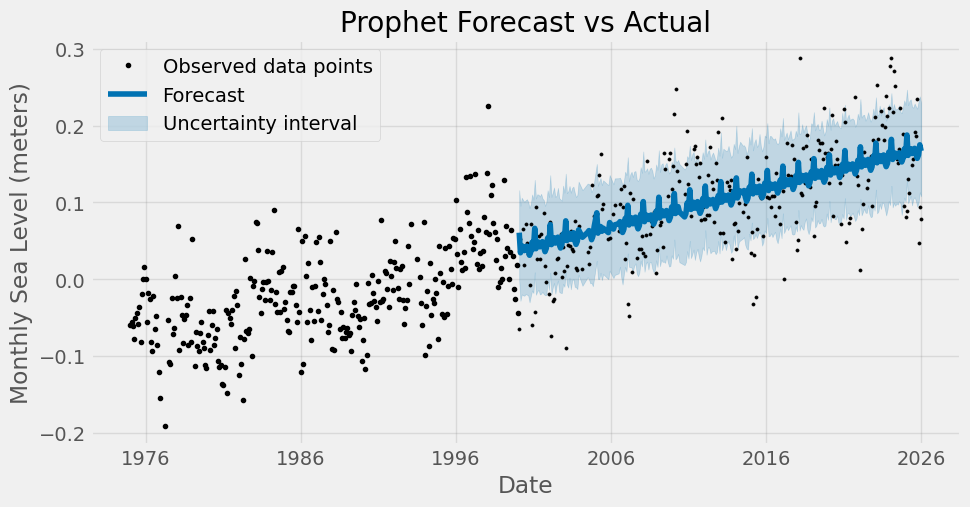

In [ ]:
# Create a figure and axis for plotting, setting the figure size
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the Prophet forecast results on the specified axis
fig = model.plot(df_test_fcst, ax=ax)

# Plot the actual values from the test set as scatter points
ax.scatter(df_test_prophet['ds'], df_test_prophet['y'], color='black', s=5)

# Set the plot title
ax.set_title('Prophet Forecast vs Actual')
yaxis = ax.get_yaxis()
yaxis.set_label_text('Monthly Sea Level (meters)')
xaxis = ax.get_xaxis()
xaxis.set_label_text('Date')

# Add a legend to differentiate between forecast and actual values
ax.legend()

# Display the plot
plt.show()

Code Block 6B

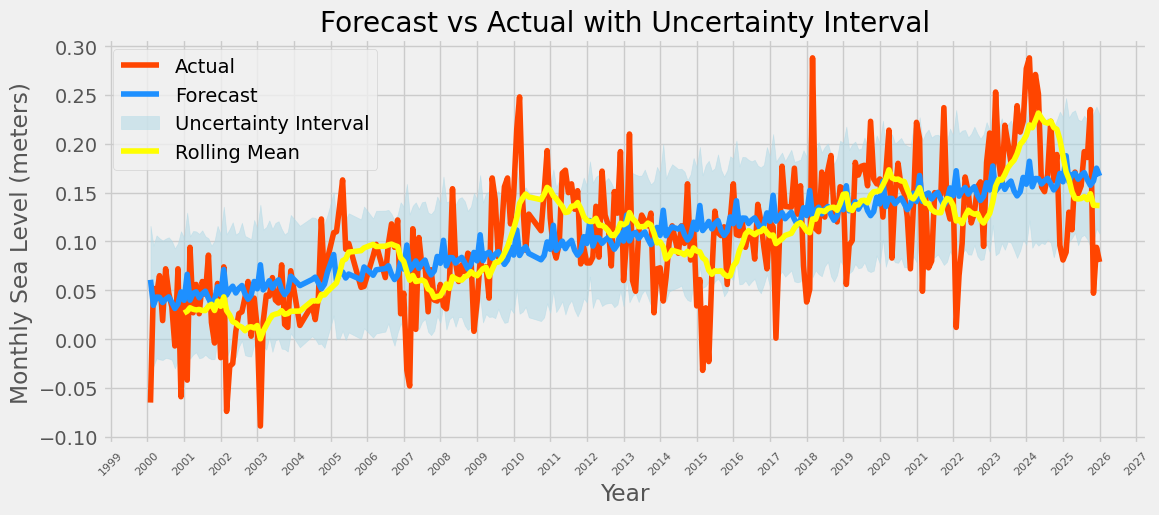

In [ ]:
# Plot forecast with actuals and confidence intervals
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_test_prophet['ds'], df_test_prophet['y'], label='Actual', color='orangered')
ax.plot(df_test_fcst['ds'], df_test_fcst['yhat'], label='Forecast', color='dodgerblue')

# Plot the confidence interval
ax.fill_between(df_test_fcst['ds'], df_test_fcst['yhat_lower'], df_test_fcst['yhat_upper'], color='lightblue', alpha=0.5, label='Uncertainty Interval')

# Add rolling average
rolling_mean = df_test_prophet['y'].rolling(window=12).mean()
ax.plot(df_test_prophet['ds'], rolling_mean, label='Rolling Mean', color='yellow')

# Format the x-axis to show only years
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, fontsize=8)

# Add axis titles
ax.set_xlabel('Year')
ax.set_ylabel('Monthly Sea Level (meters)')

# Legend
ax.legend()
ax.set_title('Forecast vs Actual with Uncertainty Interval')
plt.show()

Code Block 6C

In [ ]:
# Calculate MAE
mae = mean_absolute_error(df_test_prophet['y'], df_test_fcst['yhat'])
print(f'MAE: {mae}')

MAE: 0.040758071596034576


Code Block 6D

In [ ]:
# Calculate SMAPE
y_true = df_test_prophet['y'].values
y_pred = df_test_fcst['yhat'].values

# Filter out non-finite values
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

# Compute SMAPE
smape = 100 * np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2))
print(f'SMAPE: {smape}')

SMAPE: 46.336442413725656


Code Block 6E

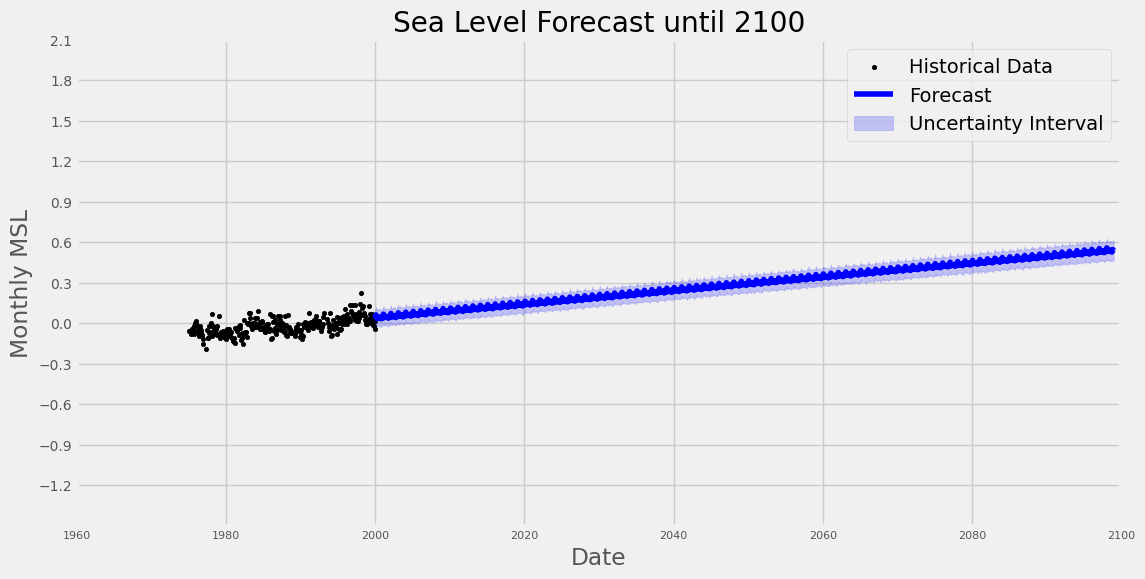

In [ ]:
# Forecast
future_dates = model.make_future_dataframe(periods=(2100 - int(split_date.split("-")[0]) - 1) * 12, freq='MS')
forecast = model.predict(future_dates)

# Split history & future
history_end = split_date
forecast_future = forecast[forecast['ds'] >= history_end]
forecast_history = forecast[forecast['ds'] < history_end]

# Plot
plt.figure(figsize=(12,6))

# Historical data (actuals)
plt.scatter(model.history['ds'], model.history['y'], color='black', label='Historical Data', s=10)

# Forecast line for future
plt.plot(forecast_future['ds'], forecast_future['yhat'], color='blue', label='Forecast')

# Confidence interval for future
plt.fill_between(forecast_future['ds'],
                 forecast_future['yhat_lower'],
                 forecast_future['yhat_upper'],
                 color='blue', alpha=0.2, label='Uncertainty Interval')

# Labels & limits
plt.title('Sea Level Forecast until 2100')
plt.xlabel('Date')
plt.ylabel('Monthly MSL')
plt.ylim(-1.5, 2.1)
plt.yticks(np.arange(-1.2, 2.4, 0.3), fontsize=10)
plt.xlim(pd.to_datetime('1960-01-01'), pd.to_datetime('2100-01-01'))
plt.xticks(fontsize=8)
plt.legend()
plt.show()